<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_981/291166343.py:14: SyntaxWarning: invalid escape sequence '\p'
  \alpha(x, y)= \pi(y)/ \pi(x) \times q(y, x)/q(x, y)
/tmp/ipykernel_981/291166343.py:41: SyntaxWarning: invalid escape sequence '\m'
  y \mid x ~ N(x, \sigma^2 I)


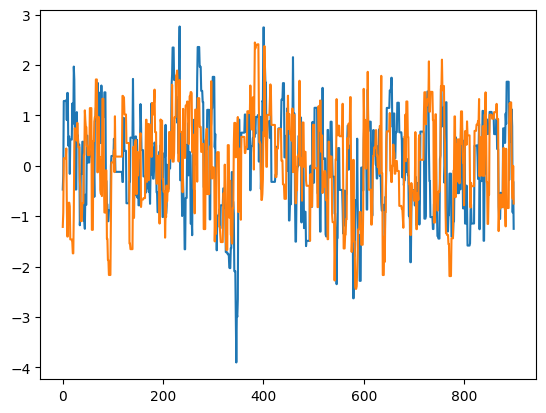

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

def make_rwmh(log_tgt_density, log_proposal_density, proposal_sampler):
  """
    log_proposal_density(x, y): log density of the proposal evaluated at y given x
    proposal_sampler: a function such that proposal_sampler(x) returns a sample y from the proposal given x
  """

  def log_acceptance_rate(x, y):
    """
      The acceptance rate in the MH algorithm is defined by
        \alpha(x, y)= \pi(y)/ \pi(x) \times q(y, x)/q(x, y)
    """
    return log_tgt_density(y)-log_tgt_density(x)+log_proposal_density(y, x)-log_proposal_density(x, y)

  def rwmh(seed, length_chain, n_burnin, x0_init):
    np.random.seed(seed)
    res = np.zeros(shape=(length_chain, *x0_init.shape))
    for i in range(1, length_chain):
      x = res[i-1]
      y = proposal_sampler(x)
      log_accpt_rate = log_acceptance_rate(x, y)
      u = np.random.uniform()
      res[i] = y if np.log(u)<=log_accpt_rate else x
    return res[n_burnin:]

  return rwmh

def make_tgt_log_density(rho):
  mean = np.zeros(shape=(2,))
  cov = np.array([[1, rho], [rho, 1]])
  def tgt_log_density(x):
    return scipy.stats.multivariate_normal.logpdf(x, mean=mean, cov=cov)
  return tgt_log_density

def make_proposal(sigma):
  """
  We set as a proposal:
  y \mid x ~ N(x, \sigma^2 I)
  """
  def log_proposal_density(x, y):
    return scipy.stats.multivariate_normal.logpdf(y, mean=x, cov=sigma**2*np.eye(2))
  def proposal_sampler(x):
    return np.random.multivariate_normal(mean=x, cov=sigma**2*np.eye(2))
  return log_proposal_density, proposal_sampler
my_log_tgt_density = make_tgt_log_density(rho=0.25)
my_log_proposal_density, my_proposal_sampler = make_proposal(2.38**0.5/1.41)
my_rwmh = make_rwmh(my_log_tgt_density, my_log_proposal_density, my_proposal_sampler)

n_burnin = 100
length_chain = 1000
x0_init = np.zeros(shape=(2, ))
seed = 1
my_samples = my_rwmh(seed, length_chain, n_burnin, x0_init)

plt.plot(range(len(my_samples)), my_samples)
plt.show()





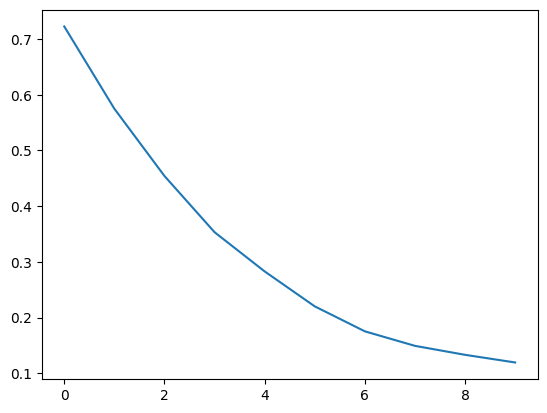

In [ ]:
def acf(my_samples, total_lag):
  n = len(my_samples)
  my_acf = np.zeros(shape=(total_lag, ))
  mean = np.mean(my_samples, axis=0)
  cov = np.mean((my_samples - mean)**2, axis=0)
  for k in range(1, total_lag+1):
    my_acf[k-1] = np.mean((my_samples[k:]-mean)*(my_samples[:n-k]-mean), axis=0).mean()
  return my_acf

plt.plot(range(10), acf(my_samples, total_lag=10))

/tmp/ipykernel_981/3662100166.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  autocorrelation_at_order_1_per_sigma[idx] = acf(my_samples, total_lag=1)


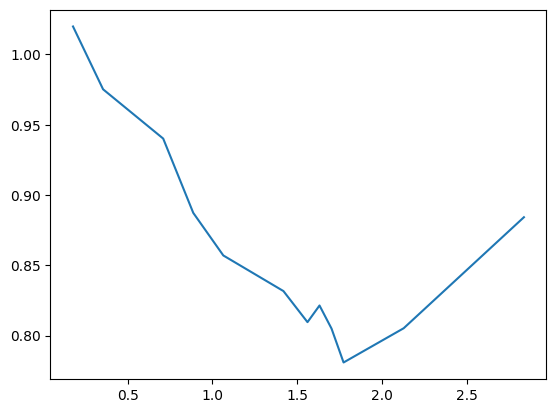

In [ ]:
"""
We are interested in finding a good proposal distribution by tuning the variance
parameter of the Gaussian proposal.
"""

set_of_sigma = np.array([0.25, 0.5, 1., 1.25, 1.5, 2., 2.2, 2.3, 2.4, 2.5, 3., 4.])/1.41
my_log_tgt_density = make_tgt_log_density(rho=0.25)

autocorrelation_at_order_1_per_sigma = np.zeros(shape=(len(set_of_sigma)))

for idx, sigma in enumerate(set_of_sigma):
  my_log_proposal_density, my_proposal_sampler = make_proposal(sigma)
  my_rwmh = make_rwmh(my_log_tgt_density, my_log_proposal_density, my_proposal_sampler)

  n_burnin = 100
  length_chain = 10000
  x0_init = np.zeros(shape=(2, ))
  seed = 1
  my_samples = my_rwmh(seed, length_chain, n_burnin, x0_init)
  autocorrelation_at_order_1_per_sigma[idx] = acf(my_samples, total_lag=1)

plt.plot(set_of_sigma, autocorrelation_at_order_1_per_sigma)
"""
Optimum is known for Gaussian distributions to be at 0.234 acceptance rate
with proposal variance parameter 2.38**2/d.
Empirically we observe the first order autocorrelation is minimised
at \sigma\approx2.38/sqrt(2)~=1.68
"""

In [ ]:
"""
Same as previously but in Jax
"""
import jax
import jax.numpy as jnp
from jax import random, lax, vmap
from functools import partial


def make_log_target_density(rho):
    cov = jnp.array([[1, rho], [rho, 1]])
    prec = jnp.linalg.inv(cov)

    def log_target_density(x):
        return - 0.5 * jnp.einsum('i,ij,j->', x, prec, x)

    return log_target_density


def make_rwmh(log_target_density, proposal, log_proposal_density):


    def log_ratio(x, y):
        return (
                log_target_density(y)
                - log_target_density(x)
                + log_proposal_density(y, x)
                - log_proposal_density(x, y)
        )

    def rwmh_single(key, x0, n_samples, burnin):
        keys = random.split(key, n_samples)

        def body_fun(i, state):
            samples = state
            x_prev = samples[i - 1]

            key_prop, key_acc = random.split(keys[i])

            x_prop = proposal(key_prop, x_prev)
            log_alpha = log_ratio(x_prev, x_prop)

            accept = jnp.log(random.uniform(key_acc)) < log_alpha
            x_new = jnp.where(accept, x_prop, x_prev)

            samples = samples.at[i].set(x_new)

            return samples

        samples = jnp.zeros((n_samples, *x0.shape))
        samples = samples.at[0].set(x0)

        samples = lax.fori_loop(
            1, n_samples, body_fun, samples
        )

        return samples[burnin:]

    return rwmh_single


In [ ]:
dim = 2
rho = 0.9
cov = jnp.array([[1, rho], [rho, 1]])
chol = jax.scipy.linalg.cholesky(cov)
prec_c = jax.scipy.linalg.inv(cov)
def proposal(key, x):
    eps = random.normal(key, shape=(dim,))
    return x + chol @ eps

def log_proposal_density(x, y):
  """
  Defining the log of the Gaussian proposal density.
  Bonus Question: Do we really need it in this case?
  """
    diff = y - x
    solve = jnp.linalg.solve(chol, diff)
    return -0.5 * jnp.dot(solve, solve) #-0.5*jnp.einsum('i,ij,j', diff, prec_c, diff)

log_target_density = make_log_target_density(rho)
rwmh = make_rwmh(log_target_density, proposal, log_proposal_density)

rwmh_vmap = vmap(
    rwmh,
    in_axes=(0, None, None, None)  # only keys are batched
)


n_chains = 10
keys = random.split(random.PRNGKey(0), n_chains)
x0 = jnp.zeros((cov.shape[0],))

samples = rwmh_vmap(keys, x0, 1000, 100) # output has shape (number of keys, length of chain - burnin, *shape of x_0)

(array([  1.,   5.,   5.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,   7.,
          0.,   4.,   6.,   8.,   3.,   0.,   7.,   4.,   1.,   7.,   5.,
          4.,  12.,   7.,  28.,   8.,   5.,  18.,  30.,  43.,  47.,  51.,
         54.,  85.,  70.,  73., 109.,  91., 101., 136., 155., 173., 206.,
        257., 205., 270., 255., 226., 283., 302., 229., 251., 243., 289.,
        280., 198., 257., 317., 235., 291., 290., 225., 268., 222., 210.,
        198., 168., 179., 141., 129., 148., 139., 118.,  85., 110.,  70.,
         56.,  49.,  21.,  20.,  32.,  22.,  14.,  30.,  17.,  12.,  16.,
         17.,   6.,   4.,   3.,   0.,  10.,   1.,   6.,   1.,   0.,   0.,
          2.]),
 array([-4.45353413, -4.37477112, -4.29600859, -4.21724558, -4.13848257,
        -4.05971956, -3.98095679, -3.90219402, -3.82343102, -3.74466825,
        -3.66590548, -3.58714247, -3.5083797 , -3.42961693, -3.35085392,
        -3.27209091, -3.19332814, -3.11456537, -3.03580236, -2.95703936,
        -2.87827659, -2.79

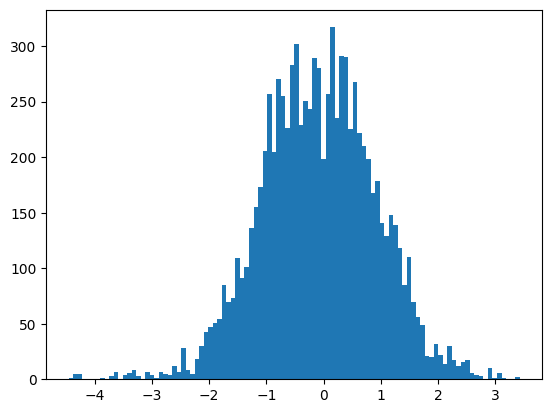

In [ ]:
import matplotlib.pyplot as plt
plt.hist(samples[..., 0].reshape(-1), bins=100)